In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 20
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

In [14]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

def plot_activity_helper(activity, n, m, channel_idx, cmap='viridis'):
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity).item()
    vmax = torch.max(activity).item()
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step+1}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idxs,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    activity = torch.clamp(activity, max=10)
    plot_activity_helper(torch.mean(activity, axis=1), n, m, "all", cmap)
    
    if channel_idxs is None:
        channel_idxs = np.arange(activity.shape[1])
        
    for channel_idx in channel_idxs:
        channel_activity = activity[:, channel_idx]
        plot_activity_helper(channel_activity, n, m, channel_idx, cmap)

def plot(sample_indices,ablater=None):
    # Main plotting loop
    for plot_idx, sample_idx in enumerate(sample_indices):
        inp, label = inputs[sample_idx], labels[sample_idx]
        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
        activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                .detach().cpu()[0]  # shape (T, C)

        plot_channel_activity_solo(activity, channels_to_plot, n, m)

In [11]:
# ——— User‐set paths & names ———
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    # also used as epoch

# ReLU
wandb_name = "earnest-planet-436"
checkpoint = 800

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
excitatory = True
n, m = 4, 5  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = [] #None #[0, 1, 2, 3] 
sample_indices = [0, 1, 2, 3, 4, 5]
do_highlight_self_kernel = False

/tmp/ipykernel_2652197/3650338800.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

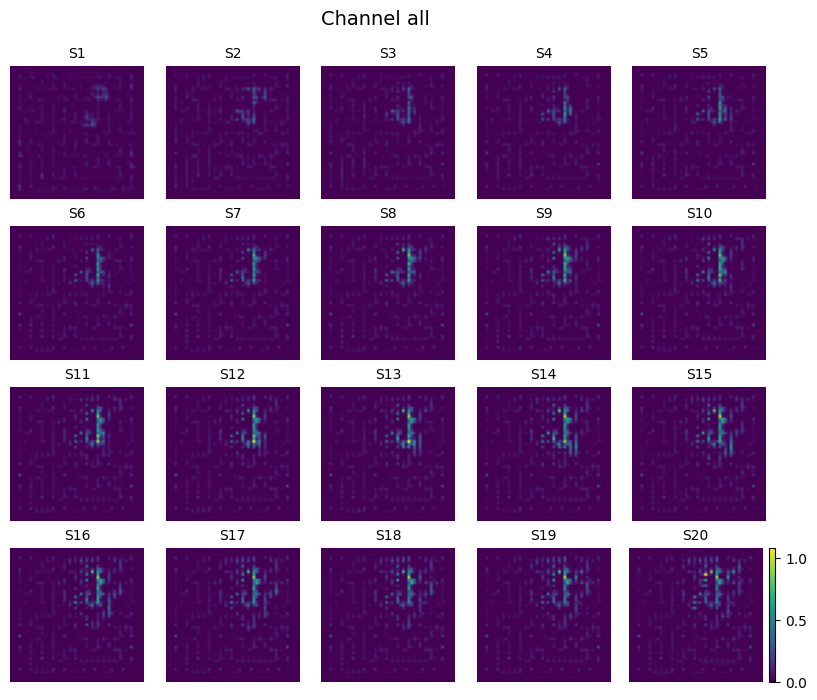

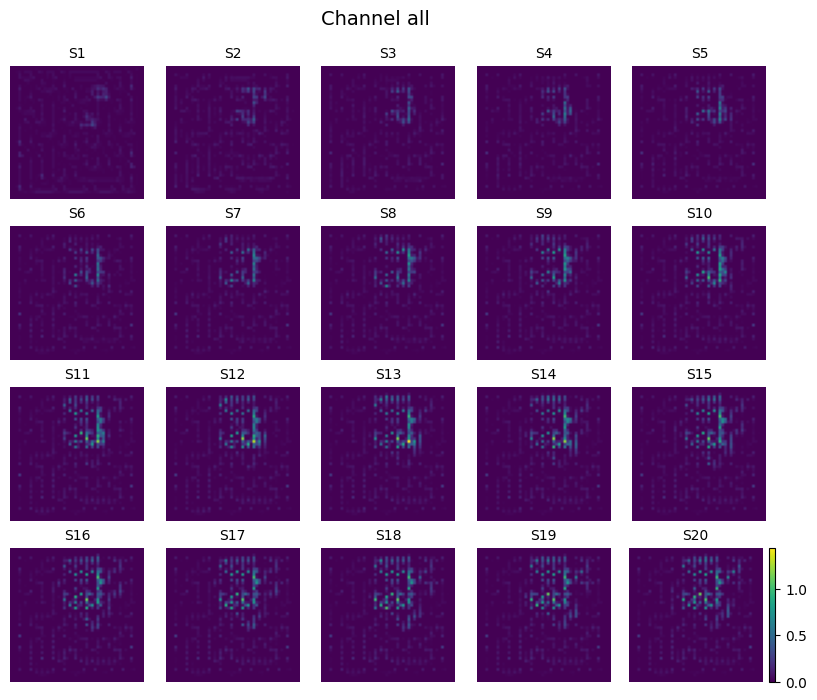

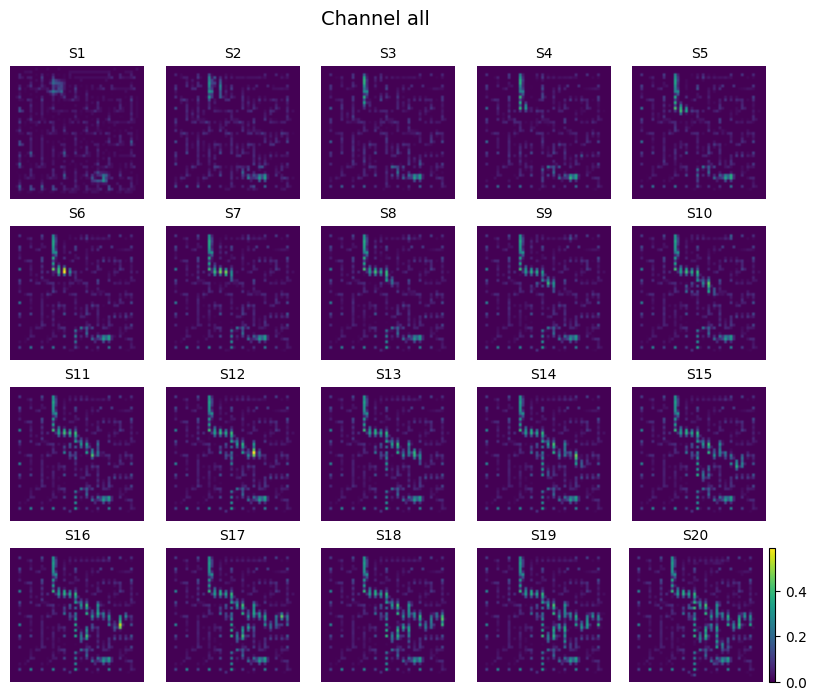

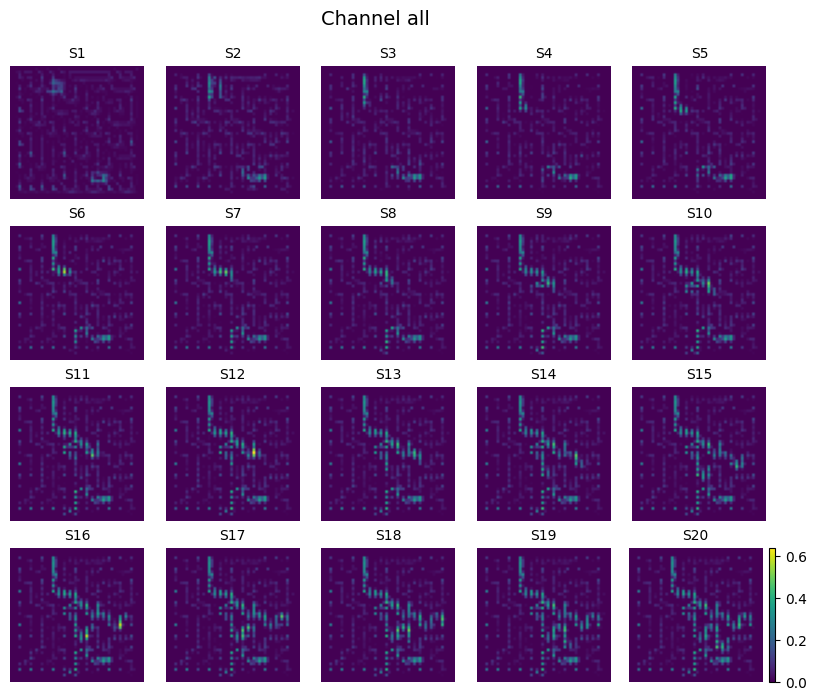

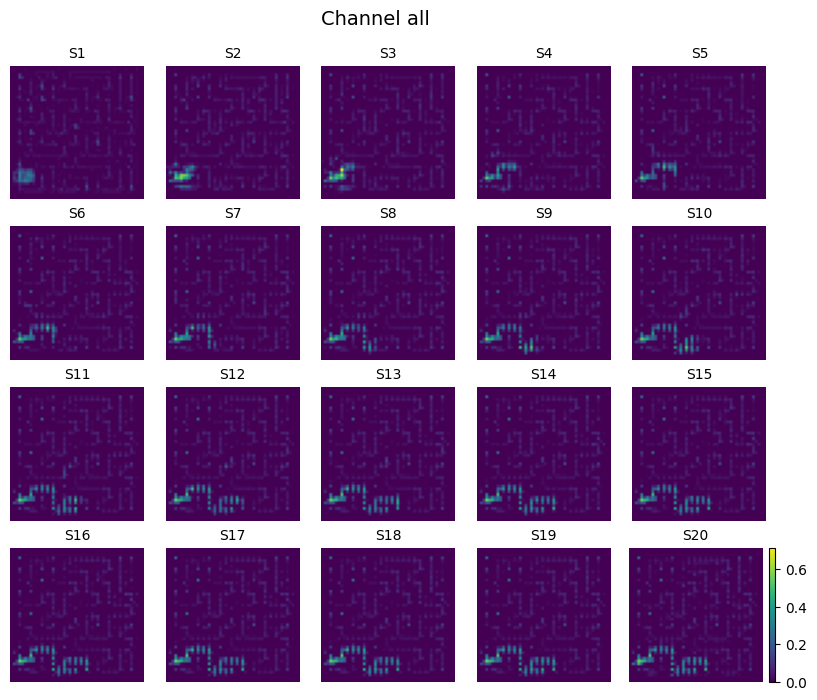

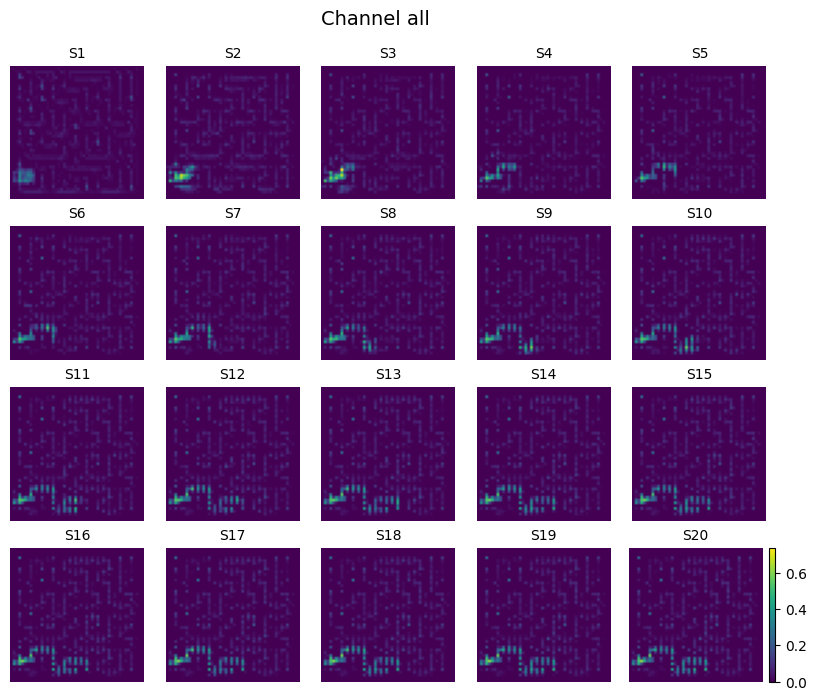

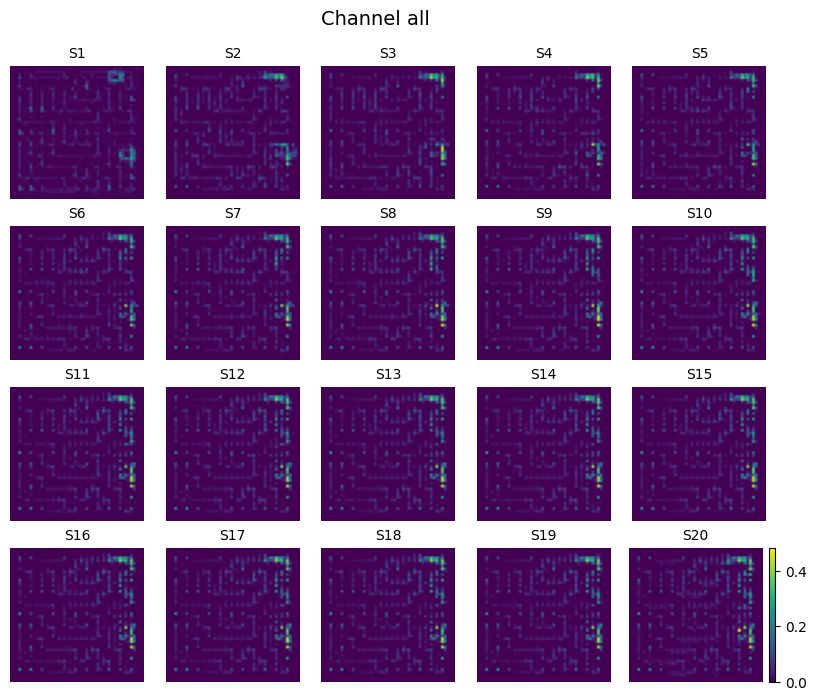

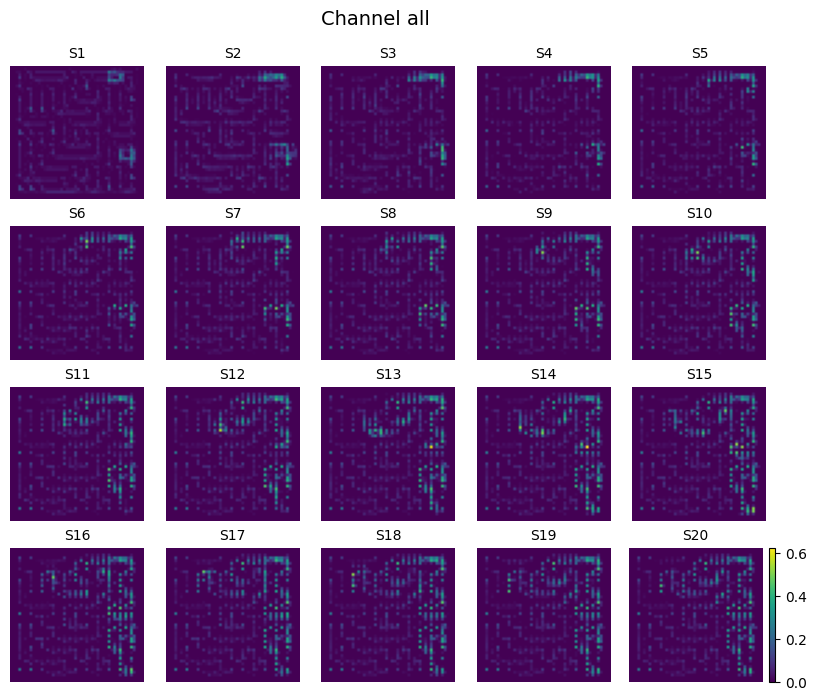

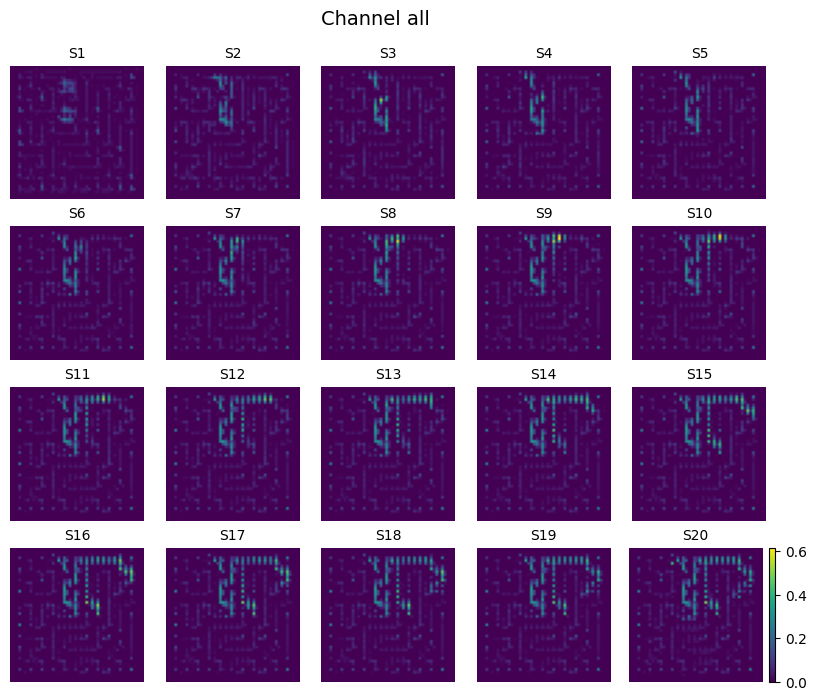

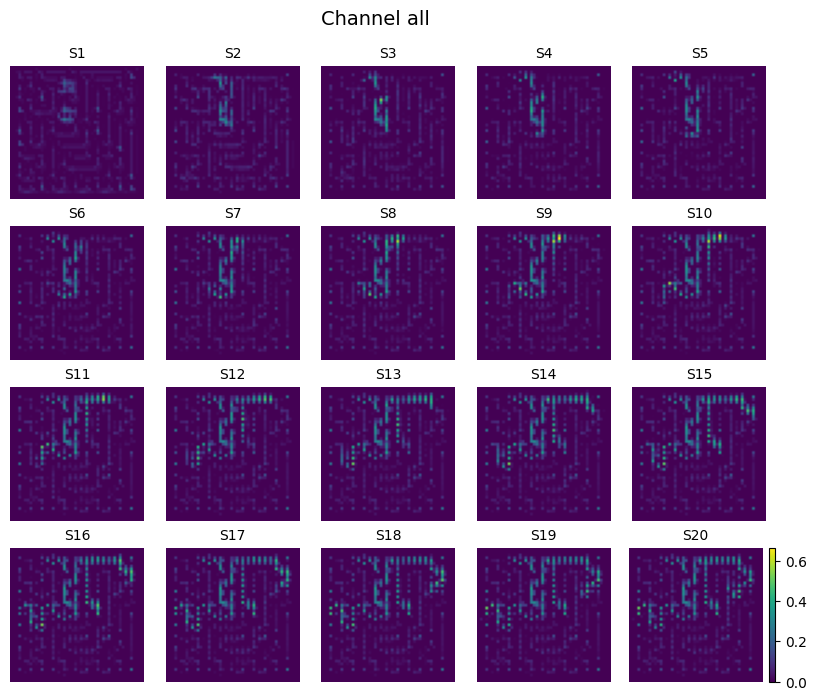

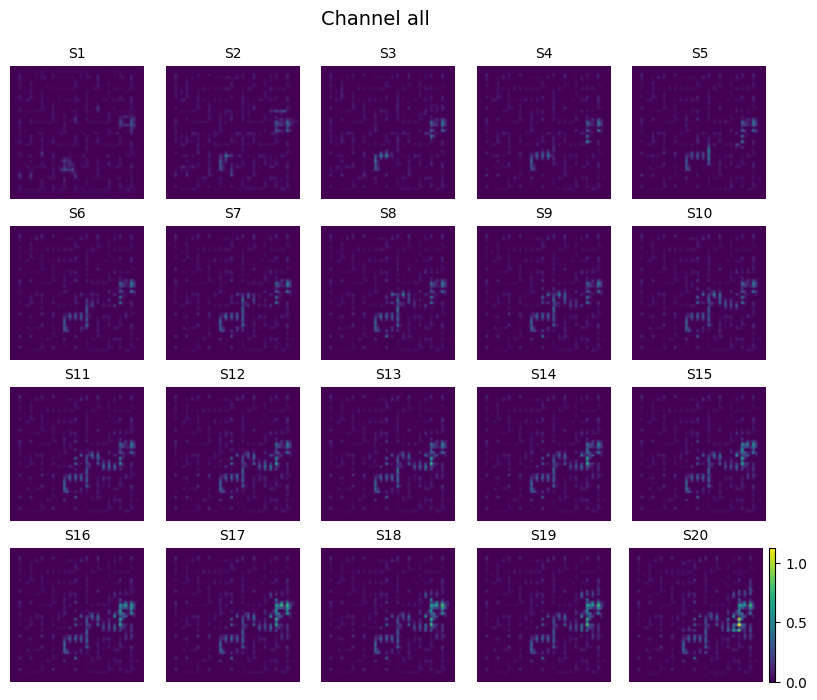

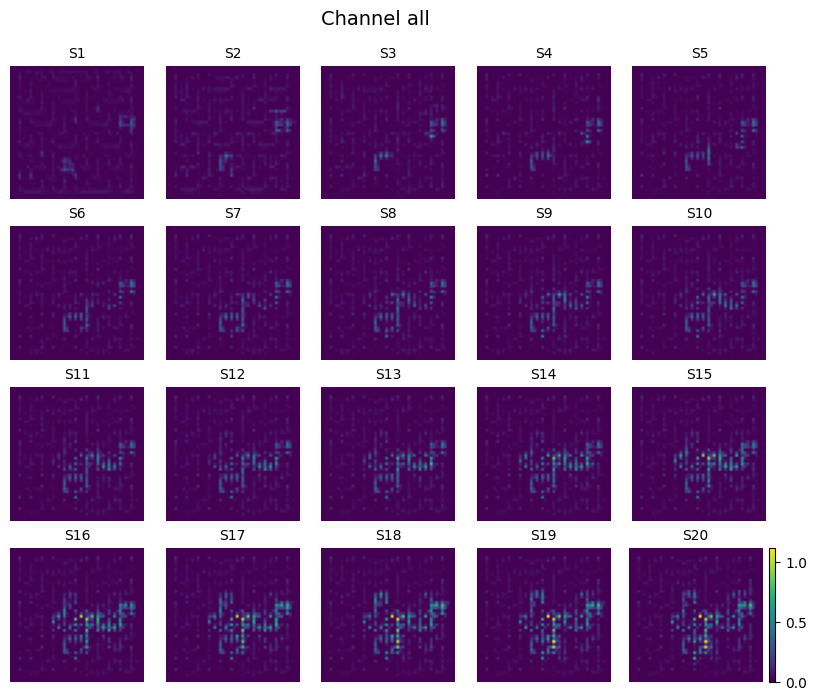

In [19]:
# ——— Define Ablations ———
# time_step: area: Ablation

#neuron_type: neuron_index: ablation type
neuron_ablation_config = {
    0:
    {
        4: "zero"
    }
}

#Connection (i->j):(in_channel, out_channel):ablation_type
channel = 1
connection_ablation_config = {
    "2->0": 
    {
        (0, channel): "zero",
        (1, channel): "zero",
        (2, channel): "zero",
        (3, channel): "zero",
    }
}

ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}

# ablater = {i:  {0: Ablation(connection_ablation_config=connection_ablation_config)} for i in range(num_steps)}

for i in sample_indices:
    plot([i], ablater=ablater)
    plot([i], ablater=None)

# White noise testing

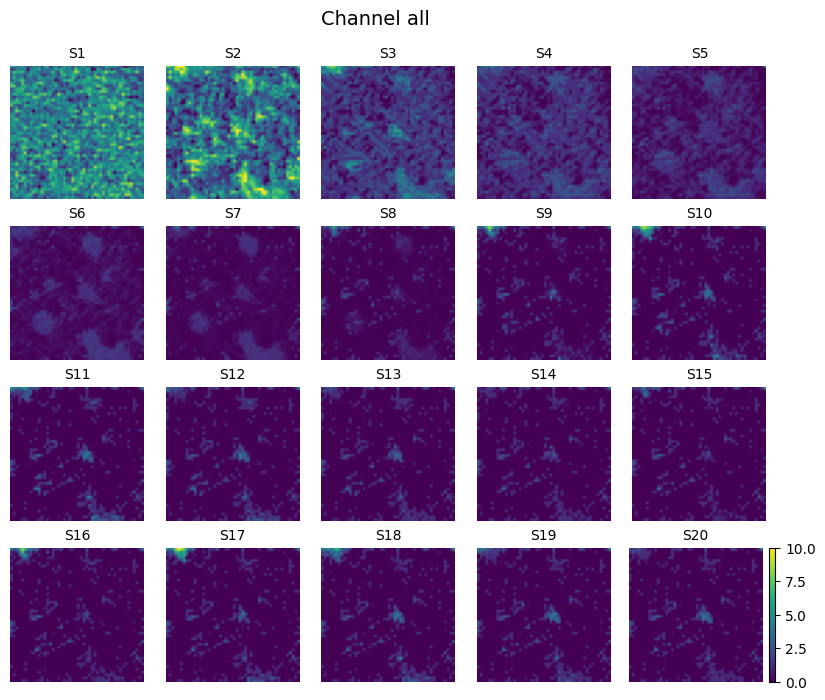

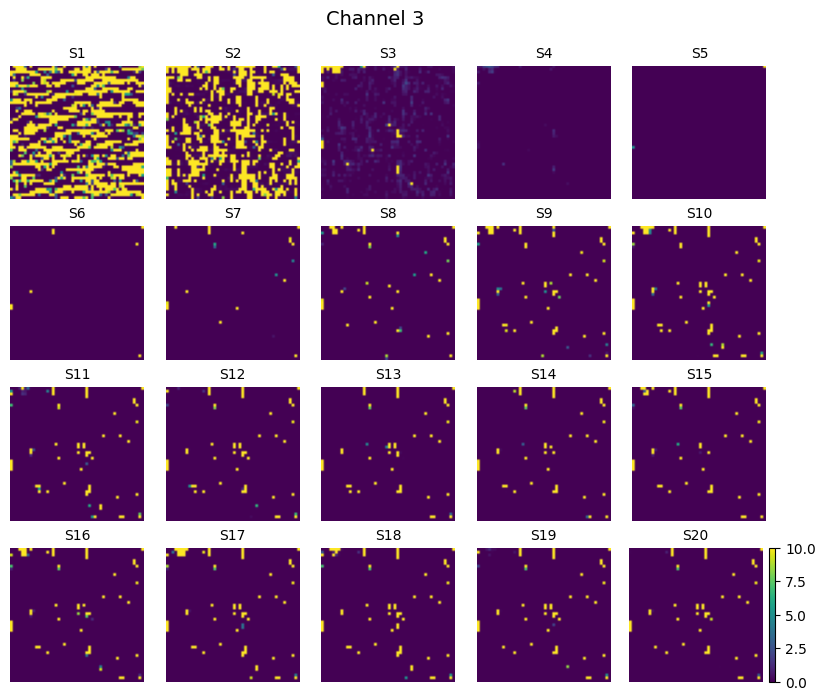

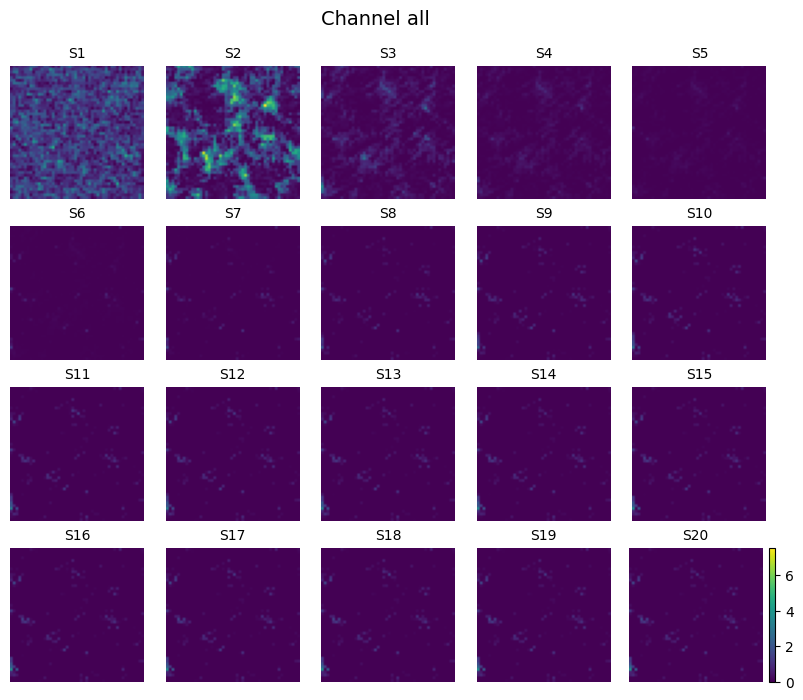

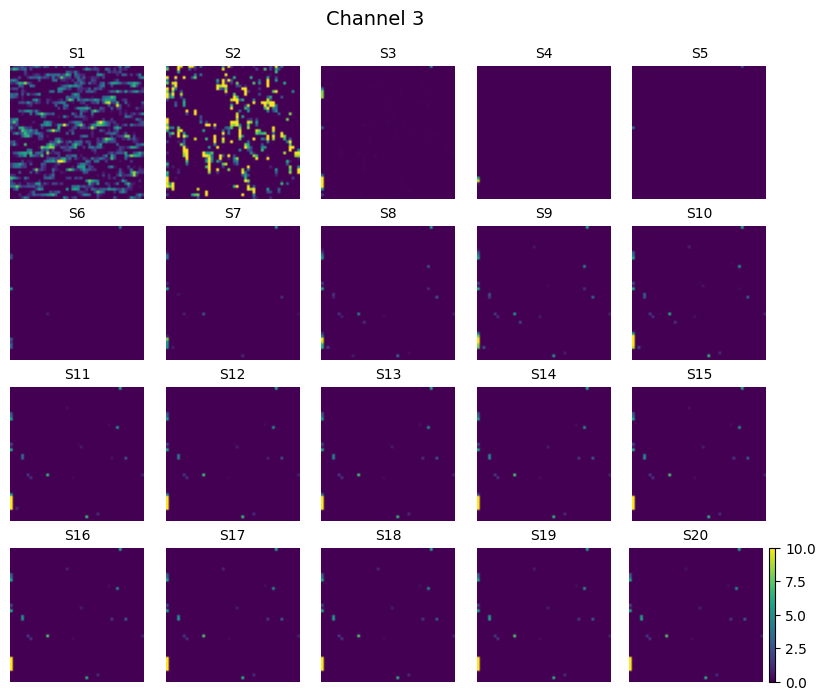

In [167]:
neuron_ablation_config = {
    1:
    {
        # 0: "zero",
        # 1: "zero",
        # 2: "zero",
        3: "zero"
    }
}

ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}
inp = torch.randn_like(inputs[0]) * 10
_, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
        .detach().cpu()[0]  # shape (T, C)

plot_channel_activity_solo(activity, channels_to_plot, n, m)

ablater = None
inp = torch.randn_like(inputs[0])
_, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
        .detach().cpu()[0]  # shape (T, C)

plot_channel_activity_solo(activity, channels_to_plot, n, m)